In [1]:
import torch

In [2]:
import torch.nn as nn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
%matplotlib inline

df = pd.read_csv('income.csv')

In [3]:

print(len(df))
df.head()

30000


,age,sex,education,education-num,marital-status,workclass,occupation,hours-per-week,income,label
0,27,Male,HS-grad,9,Never-married,Private,Craft-repair,40,<=50K,0
1,47,Male,Masters,14,Married,Local-gov,Exec-managerial,50,>50K,1
2,59,Male,HS-grad,9,Divorced,Self-emp,Prof-specialty,20,<=50K,0
3,38,Female,Prof-school,15,Never-married,Federal-gov,Prof-specialty,57,>50K,1
4,64,Female,11th,7,Widowed,Private,Farming-fishing,40,<=50K,0


In [4]:
df['label'].value_counts()

label
0    21700
1     8300
Name: count, dtype: int64

In [5]:
df.columns

Index(['age', 'sex', 'education', 'education-num', 'marital-status',
       'workclass', 'occupation', 'hours-per-week', 'income', 'label'],
      dtype='str')

In [8]:
# CODE HERE


cat_cols = ['workclass', 'education', 'marital-status', 'occupation', 'sex']
cont_cols = ['age', 'hours-per-week']
y_col = ['label']




# RUN THIS CODE TO COMPARE RESULTS:
print(f'cat_cols  has {len(cat_cols)} columns')
print(f'cont_cols has {len(cont_cols)} columns')
print(f'y_col     has {len(y_col)} column')

cat_cols  has 5 columns
cont_cols has 2 columns
y_col     has 1 column


In [9]:
# CODE HERE


for col in cat_cols:
    df[col] = df[col].astype('category')

In [10]:
# THIS CELL IS OPTIONAL
df = shuffle(df, random_state=101)
df.reset_index(drop=True, inplace=True)
df.head()

,age,sex,education,education-num,marital-status,workclass,occupation,hours-per-week,income,label
0,23,Female,HS-grad,9,Never-married,Private,Other-service,50,<=50K,0
1,37,Female,Prof-school,15,Married,State-gov,Prof-specialty,39,>50K,1
2,34,Male,Some-college,10,Divorced,Private,Adm-clerical,40,<=50K,0
3,31,Male,HS-grad,9,Married,Private,Craft-repair,40,>50K,1
4,20,Female,Some-college,10,Never-married,Private,Sales,25,<=50K,0


In [11]:

# CODE HERE

cat_szs = [len(df[col].cat.categories) for col in cat_cols]
emb_szs = [(size, min(50, (size + 1) // 2)) for size in cat_szs]

In [12]:
# CODE HERE

cats = np.stack([df[col].cat.codes.values for col in cat_cols], axis=1)

cats = cats.astype(np.int64)

# RUN THIS CODE TO COMPARE RESULTS
cats[:5]

array([[ 2, 10,  3,  6,  0],
       [ 4, 12,  1,  7,  0],
       [ 2, 13,  0,  0,  1],
       [ 2, 10,  1,  1,  1],
       [ 2, 13,  3,  9,  0]])

In [13]:
# CODE HERE
cats = torch.tensor(cats, dtype=torch.int64)

In [14]:
# CODE HERE
conts = np.stack([df[col].values for col in cont_cols], axis=1)

conts = conts.astype(np.float32)


# RUN THIS CODE TO COMPARE RESULTS
conts[:5]

array([[23., 50.],
       [37., 39.],
       [34., 40.],
       [31., 40.],
       [20., 25.]], dtype=float32)

In [15]:
# CODE HERE
conts = torch.tensor(conts, dtype=torch.float)

# RUN THIS CODE TO COMPARE RESULTS
conts.dtype

torch.float32

In [16]:

label_col = ['label']

y = torch.tensor(df[label_col].values.flatten(), dtype=torch.long)

In [17]:

# CODE HERE
batch_size = 30000 # suggested batch size
test_size = 5000  # suggested test size
cat_train = cats[:batch_size-test_size]
cat_test = cats[batch_size-test_size:batch_size]

con_train = conts[:batch_size-test_size]
con_test = conts[batch_size-test_size:batch_size]

y_train = y[:batch_size-test_size]
y_test = y[batch_size-test_size:batch_size]

In [18]:
class TabularModel(nn.Module):

    def __init__(self, emb_szs, n_cont, out_sz, layers, p=0.5):
        # Call the parent __init__
        super().__init__()
        
        # Set up the embedding, dropout, and batch normalization layer attributes
        self.embeds = nn.ModuleList([nn.Embedding(ni, nf) for ni,nf in emb_szs])
        self.emb_drop = nn.Dropout(p)
        self.bn_cont = nn.BatchNorm1d(n_cont)
        
        # Assign a variable to hold a list of layers
        layerlist = []
        
        # Assign a variable to store the number of embedding and continuous layers
        n_emb = sum((nf for ni,nf in emb_szs))
        n_in = n_emb + n_cont
        
        # Iterate through the passed-in "layers" parameter (ie, [200,100]) to build a list of layers
        for i in layers:
            layerlist.append(nn.Linear(n_in,i)) 
            layerlist.append(nn.ReLU(inplace=True))
            layerlist.append(nn.BatchNorm1d(i))
            layerlist.append(nn.Dropout(p))
            n_in = i
        layerlist.append(nn.Linear(layers[-1],out_sz))
        
        # Convert the list of layers into an attribute
        self.layers = nn.Sequential(*layerlist)
    
    def forward(self, x_cat, x_cont):
        # Extract embedding values from the incoming categorical data
        embeddings = []
        for i,e in enumerate(self.embeds):
            embeddings.append(e(x_cat[:,i]))
        x = torch.cat(embeddings, 1)
        # Perform an initial dropout on the embeddings
        x = self.emb_drop(x)
        
        # Normalize the incoming continuous data
        x_cont = self.bn_cont(x_cont)
        x = torch.cat([x, x_cont], 1)
        
        # Set up model layers
        x = self.layers(x)
        return x

In [19]:
# CODE HERE
torch.manual_seed(32)

In [20]:
model = TabularModel(
    emb_szs,
    n_cont=2,
    out_sz=2,
    layers=[50, 30],
    p=0.4
)

model

TabularModel(
  (embeds): ModuleList(
    (0): Embedding(5, 3)
    (1): Embedding(14, 7)
    (2): Embedding(6, 3)
    (3): Embedding(12, 6)
    (4): Embedding(2, 1)
  )
  (emb_drop): Dropout(p=0.4, inplace=False)
  (bn_cont): BatchNorm1d(2, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layers): Sequential(
    (0): Linear(in_features=22, out_features=50, bias=True)
    (1): ReLU(inplace=True)
    (2): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=50, out_features=30, bias=True)
    (5): ReLU(inplace=True)
    (6): BatchNorm1d(30, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=30, out_features=2, bias=True)
  )
)

In [21]:
# CODE HERE

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [22]:
import time
start_time = time.time()

epochs = 300
losses = []

for i in range(epochs):
    i+=1
    y_pred = model(cat_train, con_train)
    loss = criterion(y_pred, y_train)
    losses.append(loss)
    
    # a neat trick to save screen space:
    if i%25 == 1:
        print(f'epoch: {i:3}  loss: {loss.item():10.8f}')

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

print(f'epoch: {i:3}  loss: {loss.item():10.8f}') # print the last line
print(f'\nDuration: {time.time() - start_time:.0f} seconds') # print the time elapsed

epoch:   1  loss: 0.87438530
epoch:  26  loss: 0.59141982
epoch:  51  loss: 0.52321154
epoch:  76  loss: 0.48152086
epoch: 101  loss: 0.45371532
epoch: 126  loss: 0.43494508
epoch: 151  loss: 0.40927750
epoch: 176  loss: 0.38593134
epoch: 201  loss: 0.36968875
epoch: 226  loss: 0.35463923
epoch: 251  loss: 0.34222397
epoch: 276  loss: 0.33528855
epoch: 300  loss: 0.32612094

Duration: 18 seconds


Text(0.5, 0, 'epoch')

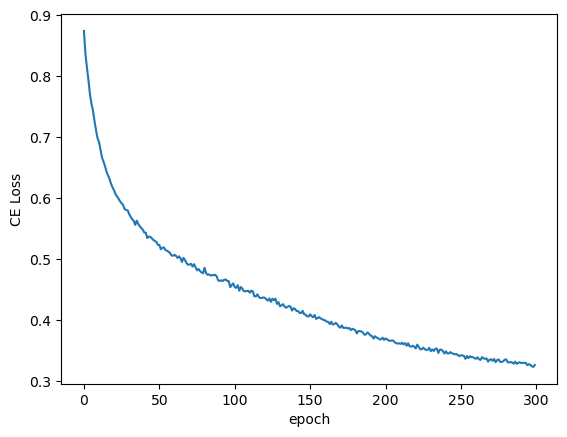

In [23]:
plt.plot(range(epochs), [loss.detach().numpy() for loss in losses])
plt.ylabel('CE Loss')
plt.xlabel('epoch')

In [24]:
# CODE HERE

with torch.no_grad():
    y_val = model(cat_test, con_test)
    loss = criterion(y_val, y_test)


# RUN THIS CODE TO COMPARE RESULTS
print(f'CE Loss: {loss:.8f}')

CE Loss: 0.34585226


In [25]:
correct = 0

with torch.no_grad():
    y_val = model(cat_test, con_test)
    predicted = torch.max(y_val, 1)[1]
    correct += (predicted == y_test).sum()

print(f'{correct.item()}/{len(y_test)} = {correct.item()*100/len(y_test):7.3f}% correct')

4230/5000 =  84.600% correct


In [26]:
# WRITE YOUR CODE HERE:
df.iloc[-1]

age                      50
sex                    Male
education         Bachelors
education-num            13
marital-status      Widowed
workclass          Self-emp
occupation            Sales
hours-per-week           65
income                 >50K
label                     1
Name: 29999, dtype: object